In [197]:
# ---- Imports ----
import kagglehub #install this before running the notebook to download the dataset locally
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


## Data exploration

#### Load the CommonsenseQA dataset

In [198]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("thedevastator/new-commonsenseqa-dataset-for-multiple-choice-qu")
print("Path:", path)

# List files inside the dataset directory & display train df 
print(f"Files available: {os.listdir(path)}\n")
df = pd.read_csv(f"{path}/train.csv")
df

# Validation --> Use as test 
df_val = pd.read_csv(f"{path}/validation.csv", index_col=0)
df_val.index.name = "answerKey"
df_val = df_val.reset_index()
print(f"Empty rows Val: {df_val['answerKey'].isnull().sum()}\n") #checked: is 0 
print(f"Quick check: Val split distribution\n{df_val['answerKey'].value_counts().to_dict()}\n")
#df_val

# Test 
df_test = pd.read_csv(f"{path}/test.csv", index_col=0)
df_test.index.name = "answerKey"
df_test = df_test.reset_index()
print(f"Empty rows Test: {df_test['answerKey'].isnull().sum()}") #checked: no rows contain answers (1140)
#df_test


Path: /Users/aliyah/.cache/kagglehub/datasets/thedevastator/new-commonsenseqa-dataset-for-multiple-choice-qu/versions/2
Files available: ['validation.csv', 'test.csv', 'train.csv']

Empty rows Val: 0

Quick check: Val split distribution
{'B': 255, 'D': 251, 'C': 241, 'A': 239, 'E': 235}

Empty rows Test: 1140


#### Basic exploration 

In [199]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nFirst row:\n{df.iloc[0]}")

# Check for missing values 
print("\nMissing values")
print(df.isnull().sum())
print(f"Duplicate rows: {df.duplicated().sum()}")

Shape: (9741, 3)
Columns: ['answerKey', 'question', 'choices']

Dtypes:
answerKey    object
question     object
choices      object
dtype: object

First row:
answerKey                                                    A
question     The sanctions against the school were a punish...
choices      {'label': array(['A', 'B', 'C', 'D', 'E'], dty...
Name: 0, dtype: object

Missing values
answerKey    0
question     0
choices      0
dtype: int64
Duplicate rows: 0


#### Cleaning/Formatting

In [200]:
# Convert the raw string into a real Python object
print(f"Raw string (before applying parse_choices):\n{repr(df['choices'].iloc[0])}\n")

def parse_choices(raw):
    """
    Converts the stringified dict to a plain {label: text} dict
    """
    # Remove numpy array wrapper: array([...], dtype=object) ->  [...]
    cleaned = re.sub(r"array\((\[.*?\]),\s*dtype=object\)", r"\1", raw, flags=re.DOTALL)
    try:
        d = ast.literal_eval(cleaned) # So this string: {'label': array([...]), 'text': array([...])} becomes an actual dict with 2 numpy arrays inside
        return dict(zip(list(d["label"]), list(d["text"]))) #takes the 2 arrays (labels & texts), and pair them up into a clean, usable dict
    except Exception:
        return {}
 
df["choices_parsed"] = df["choices"].apply(parse_choices) #{'A': 'option1', 'B': 'option2', 'C': 'option3', ...}
df["num_choices"]    = df["choices_parsed"].apply(len)
print(f"\nChoice counts per question:\n{df['num_choices'].value_counts()}")

# Flatten all choice texts across all rows into one flat list for length analysis
all_choice_texts = [text for c in df["choices_parsed"] for text in c.values()]

# Example of parse_choices applied 
sample = df["choices"].iloc[0]
print(f"\nResulting string (after applying parse_choices):\n{parse_choices(sample)}")

Raw string (before applying parse_choices):
"{'label': array(['A', 'B', 'C', 'D', 'E'], dtype=object), 'text': array(['ignore', 'enforce', 'authoritarian', 'yell at', 'avoid'],\n      dtype=object)}"


Choice counts per question:
num_choices
5    9741
Name: count, dtype: int64

Resulting string (after applying parse_choices):
{'A': 'ignore', 'B': 'enforce', 'C': 'authoritarian', 'D': 'yell at', 'E': 'avoid'}


In [201]:
# Cleaning checks 
print("\nCleaning checklist")
unparseable = (df["num_choices"] == 0).sum()
bad_keys = df.apply(lambda r: r["answerKey"] not in r["choices_parsed"], axis=1).sum()
no_question_mark = (~df["question"].str.strip().str.endswith("?")).sum()
 
print(f" Rows with unparseable choices: {unparseable}") 
print(f" Rows where answerKey is not in choices: {bad_keys}") #all correct answers are present in options 
print(f" Questions missing trailing '?': {no_question_mark}") #not all questions have a question mark 
# Optional: drop bad rows
# df = df[df["num_choices"] > 0].reset_index(drop=True)


Cleaning checklist
 Rows with unparseable choices: 0
 Rows where answerKey is not in choices: 0
 Questions missing trailing '?': 67


#### Feature engineering & Basic statistics 

In [202]:
# Feature Engineering: question level features 
df["q_starts_with"] = df["question"].str.split().str[0].str.lower()
df["q_len_chars"] = df["question"].str.len()
df["q_len_words"] = df["question"].str.split().str.len()
df["choice_len_mean"] = df["choices_parsed"].apply(
     lambda d: np.mean([len(t) for t in d.values()]) if d else np.nan)

# Basic statistics: q&a distributions 
print("\nAnswer key distribution")
print("-"*30)
print(df["answerKey"].value_counts())

print("\nTop 10 question-opening words")
print("-"*30)
print(df["q_starts_with"].value_counts().head(10))

print("\nQuestion length (words)")
print("-"*30)
print(df["q_len_words"].describe())

print("\nQuestion length (characters)")
print("-"*30)
print(df["q_len_chars"].describe())

print("\nMean choice length")
print("-"*30)
print(df["choice_len_mean"].describe())



Answer key distribution
------------------------------
answerKey
D    1985
B    1973
C    1946
E    1928
A    1909
Name: count, dtype: int64

Top 10 question-opening words
------------------------------
q_starts_with
what     2113
where    1820
the      1267
if        649
when      285
a         278
he        261
john      199
why       186
james     180
Name: count, dtype: int64

Question length (words)
------------------------------
count    9741.000000
mean       13.249974
std         5.516564
min         3.000000
25%         9.000000
50%        12.000000
75%        16.000000
max        63.000000
Name: q_len_words, dtype: float64

Question length (characters)
------------------------------
count    9741.000000
mean       69.466893
std        29.463106
min        15.000000
25%        48.000000
50%        64.000000
75%        84.000000
max       376.000000
Name: q_len_chars, dtype: float64

Mean choice length
------------------------------
count    9741.000000
mean        9.356555
st

#### Linguistic feature analysis 
These features proxy for question difficulty and potential model failure modes (factors likely to influence where confidence and correctness diverge).


- Question difficulty signal, proxied with negation: Questions with negation words require more reasoning 
steps and models are known to struggle with them. A predefined 
[negations word list](https://aclanthology.org/P17-1154.pdf) was used for detection.

- Lexical overlap between questions and choices: If a choice reuses words from the question, a model might pick it due to surface-level matching rather than reasoning --> would show up as high confidence on a wrong answer (shortcut behaviour).

- Distractor quality (choice length variation): If all choices are very similar, the task is harder and confidence scores should be lower. If one choice is obviously different, confidence might be high but for the wrong reason

In [211]:
# Flag questions containing negations (models often struggle with these)
df["has_negation"] = df["question"].str.contains(
    r"\b(no|not|never|neither|except|nobody|nothing|nowhere|seldom|scarcely|hardly|barely|cannot|least|without|n't)\b", 
    regex=True, case=False)
#print(df["has_negation"].value_counts()) #counts 
# Convert to percentages for easy interpretation 
negation_pct = df["has_negation"].value_counts(normalize=True) * 100
print(f"Contains negation: {negation_pct[True]:.1f}%  ({df['has_negation'].sum()} questions)")
print(f"No negation: {negation_pct[False]:.1f}%  ({(~df['has_negation']).sum()} questions)")
print("-"*30)


def tokenize(text):
    return set(re.findall(r"\b\w+\b", text.lower()))

def overlap(row):
    """
    Compute word overlap between the question and each answer choice.
    Returns: dict: mapping choice key -> number of shared tokens with the question
    """
    q_words = tokenize(row["question"])
    return {k: len(q_words & set(v.lower().split())) for k, v in row["choices_parsed"].items()}

# Compute overlap scores for each choice per question
df["q_choice_overlap"] = df.apply(overlap, axis=1)
# Extract overlap score for the correct answer
df["correct_overlap"] = df.apply(lambda r: r["q_choice_overlap"].get(r["answerKey"], 0), axis=1)
# Compute maximum overlap among all answer choices
df["max_overlap"] = df["q_choice_overlap"].apply(lambda d: max(d.values()))
# Check if correct answer has the highest overlap
df["correct_is_max_overlap"] = ((df["correct_overlap"] == df["max_overlap"]) &  
    (df["max_overlap"] > 0))

overlap_pct = df["correct_is_max_overlap"].mean() * 100
# If the correct answer consistently has the highest overlap, models may be use surface-level
# word matching rather than reasoning 
print(f"Correct answer has highest word overlap with question in: {overlap_pct:.1f}% of cases")
print(f"{'-> Potential shortcut risk' if overlap_pct > 50 else '-> Limited evidence of overlap bias'}")
print("-"*30)


# Measure how much answer choices vary in length within each question.
df["choice_text_lengths"] = df["choices_parsed"].apply(
    lambda d: [len(v) for v in d.values()])
# Compute standard deviation of choice lengths (per question)
df["choice_len_std"] = df["choice_text_lengths"].apply(np.std)
print(f"Mean std across questions: {df['choice_len_std'].mean():.2f} chars")
print(f"Median std: {df['choice_len_std'].median():.2f} chars")
print(f"Questions with high variance (std > 10): {(df['choice_len_std'] > 10).sum()}")

# High variance (std) suggests uneven distractors (varying a lot in length): one choice may stand out visually,
# which can artificially increase model confidence regardless of correctness

/var/folders/2l/plrsrcxd4md3_5f0546wj6dr0000gn/T/ipykernel_46707/1311370316.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_negation"] = df["question"].str.contains(


Contains negation: 7.4%  (716 questions)
No negation: 92.6%  (9025 questions)
------------------------------
Correct answer has highest word overlap with question in: 3.2% of cases
-> Limited evidence of overlap bias
------------------------------
Mean std across questions: 3.13 chars
Median std: 2.87 chars
Questions with high variance (std > 10): 38


#### EDA Visualisations 

/var/folders/2l/plrsrcxd4md3_5f0546wj6dr0000gn/T/ipykernel_46707/2759901284.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(groups, labels=order, patch_artist=True,
/var/folders/2l/plrsrcxd4md3_5f0546wj6dr0000gn/T/ipykernel_46707/2759901284.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Plot saved -> eda_overview.png


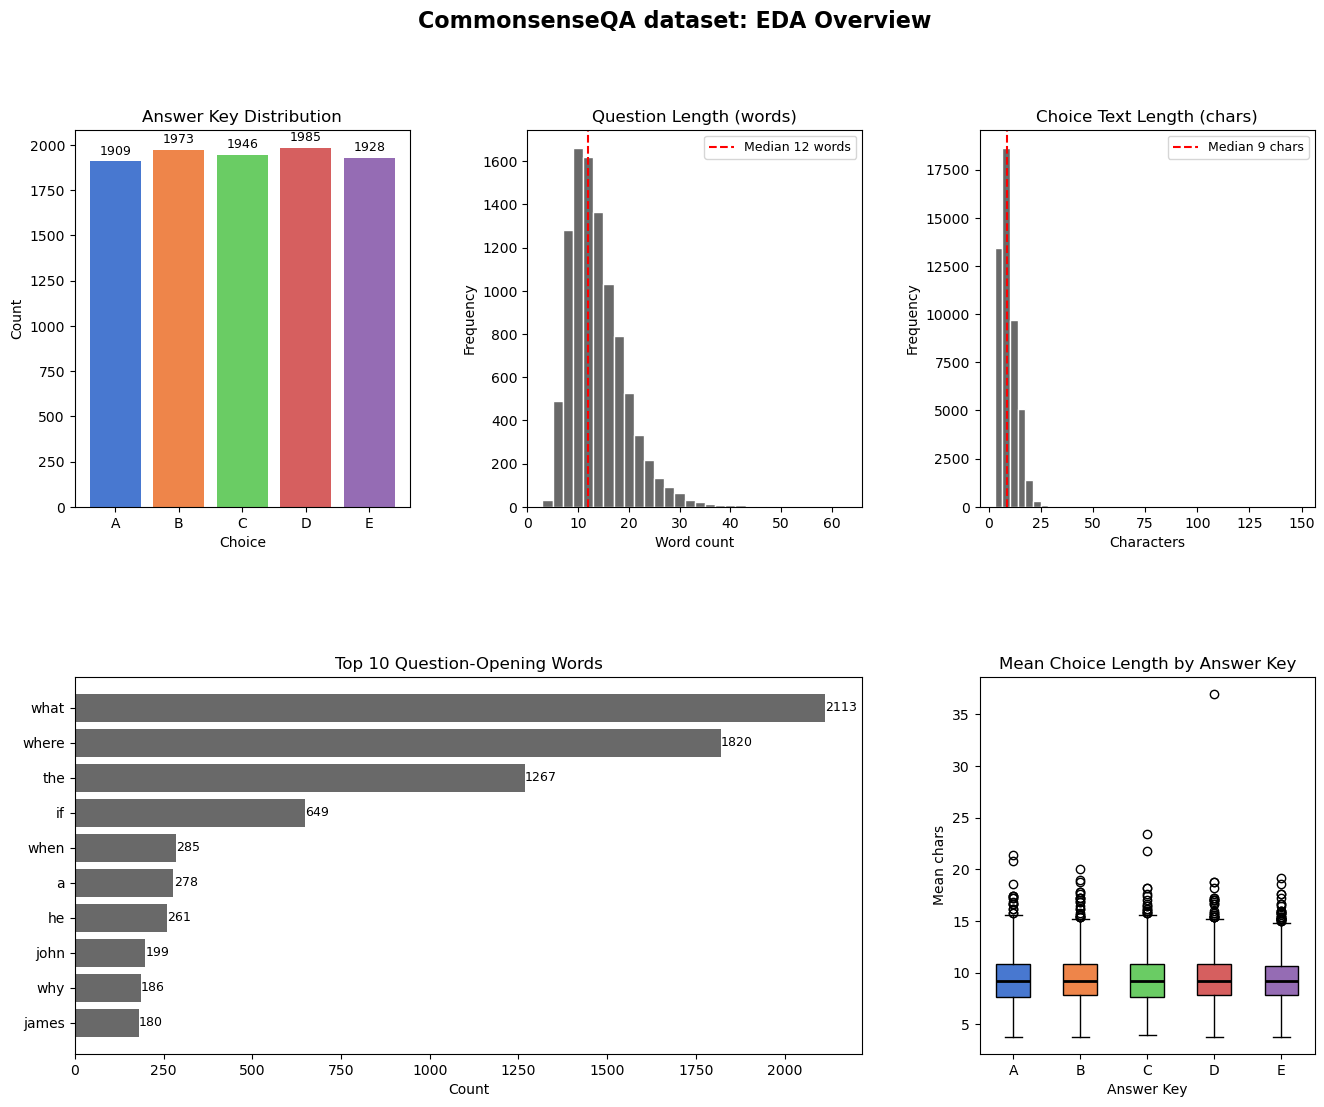

In [204]:
# Set up figure
order = sorted(df["answerKey"].dropna().unique())
fig = plt.figure(figsize=(16, 12))
fig.suptitle("CommonsenseQA dataset: EDA Overview", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35) #initialize a 2x3 grid layout for the subplots
 
# Plot A:  Answer key distribution 
ax1 = fig.add_subplot(gs[0, 0])
counts = df["answerKey"].value_counts().reindex(order)
bars = ax1.bar(order, counts.values, color=sns.color_palette("muted", len(order)))
ax1.bar_label(bars, padding=3, fontsize=9)
ax1.set_title("Answer Key Distribution")
ax1.set_xlabel("Choice"); ax1.set_ylabel("Count")
 
# Plot B: Question text length histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df["q_len_words"].dropna(), bins=30, color="dimgrey", edgecolor="white")
ax2.axvline(df["q_len_words"].median(), color="red", linestyle="--",
            label=f"Median {df['q_len_words'].median():.0f} words")
ax2.set_title("Question Length (words)")
ax2.set_xlabel("Word count"); ax2.set_ylabel("Frequency")
ax2.legend(fontsize=9)
 
# Plot C: Choice text length histogram 
ax3 = fig.add_subplot(gs[0, 2])
choice_lens = [len(t) for t in all_choice_texts]
ax3.hist(choice_lens, bins=40, color="dimgrey", edgecolor="white") 
ax3.axvline(np.median(choice_lens), color="red", linestyle="--",
            label=f"Median {np.median(choice_lens):.0f} chars")
ax3.set_title("Choice Text Length (chars)")
ax3.set_xlabel("Characters"); ax3.set_ylabel("Frequency")
ax3.legend(fontsize=9)
 
# Plot D: Top 10 question-opening words
ax4 = fig.add_subplot(gs[1, 0:2]) #span two columns instead of one 
top_starts = df["q_starts_with"].value_counts().head(10)
ax4.barh(top_starts.index[::-1], top_starts.values[::-1], color="dimgrey")
ax4.set_title("Top 10 Question-Opening Words")
ax4.set_xlabel("Count")
for i, v in enumerate(top_starts.values[::-1]):
    ax4.text(v + 0.5, i, str(v), va="center", fontsize=9)
 
# Plot E: Mean choice length by answer key
ax5 = fig.add_subplot(gs[1, 2])
groups = [df[df["answerKey"] == k]["choice_len_mean"].dropna().values for k in order]
bp = ax5.boxplot(groups, labels=order, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], sns.color_palette("muted", len(order))):
    patch.set_facecolor(color)
ax5.set_title("Mean Choice Length by Answer Key")
ax5.set_xlabel("Answer Key"); ax5.set_ylabel("Mean chars")
 
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
print("\nPlot saved -> eda_overview.png")
plt.show()
 

#### Worked examples 
(to get an intuition of what the model will see)

In [215]:
examples = df.sample(3, random_state=42)

for i, row in examples.iterrows():
    print(f"\n--- Example {i} ---")
    print("Question:", row["question"])
    print("Choices:", row["choices_parsed"])
    print("Answer:", row["answerKey"])


--- Example 3312 ---
Question: Bill sits down on a whoopee cushion, what sound does he make when he sits?
Choices: {'A': 'fall asleep', 'B': 'flatulence', 'C': 'sigh of relief', 'D': 'medium', 'E': 'comfort'}
Answer: B

--- Example 3668 ---
Question: What is likely heard by those going to a party?
Choices: {'A': 'smoking pot', 'B': 'happiness', 'C': 'laughter', 'D': 'babies', 'E': 'meet new people'}
Answer: C

--- Example 7535 ---
Question: A handsome prince is a stock character common to what?
Choices: {'A': 'england', 'B': 'fairy tale', 'C': 'castle', 'D': 'palace', 'E': 'court'}
Answer: B


## Model 1: Llama 3.2-1B / GPT-XL

## Model 2: RoBERTa